In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
raw_path = "../data/raw/"
procesed_path = "../data/processed/"

In [3]:
df = pd.read_csv(os.path.join(raw_path, "clean2.data"), header=None)

In [4]:
n_cols = df.shape[1]
columns = ["ID"] + [f"attr_{i}" for i in range(1, n_cols)]
df.columns = columns

In [5]:
df.dtypes

ID              str
attr_1          str
attr_2        int64
attr_3        int64
attr_4        int64
             ...   
attr_164      int64
attr_165      int64
attr_166      int64
attr_167      int64
attr_168    float64
Length: 169, dtype: object

In [6]:
df.shape

(6598, 169)

In [7]:
df.head()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
0,MUSK-211,211_1+1,46,-108,-60,-69,-117,49,38,-161,...,-308,52,-7,39,126,156,-50,-112,96,1.0
1,MUSK-211,211_1+10,41,-188,-145,22,-117,-6,57,-171,...,-59,-2,52,103,136,169,-61,-136,79,1.0
2,MUSK-211,211_1+11,46,-194,-145,28,-117,73,57,-168,...,-134,-154,57,143,142,165,-67,-145,39,1.0
3,MUSK-211,211_1+12,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,136,168,-60,-135,80,1.0
4,MUSK-211,211_1+13,41,-188,-145,22,-117,-7,57,-170,...,-60,-4,52,104,137,168,-60,-135,80,1.0


In [8]:
df.tail()

,ID,attr_1,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
6593,NON-MUSK-jp13,jp13_2+5,51,-123,-23,-108,-117,134,-160,82,...,-66,164,-14,-29,107,171,-44,-115,118,0.0
6594,NON-MUSK-jp13,jp13_2+6,44,-104,-19,-105,-117,142,-165,68,...,-51,166,-9,150,129,158,-66,-144,-5,0.0
6595,NON-MUSK-jp13,jp13_2+7,44,-102,-19,-104,-117,72,-165,65,...,90,117,-8,150,130,159,-66,-144,-6,0.0
6596,NON-MUSK-jp13,jp13_2+8,51,-121,-23,-106,-117,63,-161,79,...,86,99,-14,-31,106,171,-44,-116,117,0.0
6597,NON-MUSK-jp13,jp13_2+9,51,-122,-23,-106,-117,190,-161,80,...,40,124,-14,-30,107,171,-44,-115,118,0.0


Svaki red u clean2.data predstavlja jednu konformaciju molekula.
ID je naziv molekula dok su atributi koji ga prate numericke karakteristike molekula. Imamo 168 atributa po instanci koji predstavljaju razlicite karakteristike.
Kao sto vidimo prikazujuci head i tail imamo MUSK i NON-MUSK molekule.

In [9]:
df.describe()

,attr_2,attr_3,attr_4,attr_5,attr_6,attr_7,attr_8,attr_9,attr_10,attr_11,...,attr_159,attr_160,attr_161,attr_162,attr_163,attr_164,attr_165,attr_166,attr_167,attr_168
count,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,...,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000,6598.000000
mean,58.945135,-119.128524,-73.146560,-0.628372,-103.533495,18.359806,-14.108821,-1.858290,-86.003031,-44.495756,...,-184.798272,-75.795696,-26.073204,64.616702,112.037739,201.760230,-47.488330,-150.259927,41.770233,0.154138
std,53.249007,90.813375,67.956235,80.444617,64.387559,80.593655,115.315673,90.372537,108.326676,72.088903,...,107.819514,127.861271,69.727964,100.861935,72.835040,59.526751,55.069365,76.019023,94.116085,0.361108
min,-31.000000,-199.000000,-167.000000,-114.000000,-118.000000,-183.000000,-171.000000,-225.000000,-245.000000,-286.000000,...,-328.000000,-219.000000,-136.000000,-120.000000,-69.000000,73.000000,-289.000000,-428.000000,-471.000000,0.000000
25%,37.000000,-193.000000,-137.000000,-70.000000,-117.000000,-28.000000,-159.000000,-85.000000,-217.000000,-96.750000,...,-272.000000,-205.000000,-70.000000,-18.000000,71.000000,166.000000,-68.000000,-179.000000,-9.000000,0.000000
50%,44.000000,-149.000000,-99.000000,-25.000000,-117.000000,33.000000,27.000000,19.000000,-40.000000,-29.000000,...,-234.000000,-131.000000,-21.000000,61.500000,107.000000,191.000000,-60.000000,-150.000000,27.000000,0.000000
75%,53.000000,-95.000000,-19.000000,42.000000,-116.000000,74.000000,57.000000,61.000000,-21.000000,4.000000,...,-80.000000,52.000000,9.000000,149.000000,129.000000,215.000000,-45.000000,-120.000000,119.000000,0.000000
max,292.000000,95.000000,81.000000,161.000000,325.000000,200.000000,220.000000,320.000000,147.000000,231.000000,...,94.000000,179.000000,192.000000,411.000000,355.000000,625.000000,295.000000,168.000000,367.000000,1.000000


In [10]:
missing_values = df.isnull().sum()
print(missing_values)

ID          0
attr_1      0
attr_2      0
attr_3      0
attr_4      0
           ..
attr_164    0
attr_165    0
attr_166    0
attr_167    0
attr_168    0
Length: 169, dtype: int64


In [11]:
#Prikaz jednog reda
example_row = df.iloc[0]
print("Primjer prvog reda:\n", example_row)

Primjer prvog reda:
 ID          MUSK-211
attr_1       211_1+1
attr_2            46
attr_3          -108
attr_4           -60
              ...   
attr_164         156
attr_165         -50
attr_166        -112
attr_167          96
attr_168         1.0
Name: 0, Length: 169, dtype: object


In [12]:
# Primjer numeričkih atributa
print("Prvih 10 numeričkih atributa prvog reda:\n", example_row[1:11])

Prvih 10 numeričkih atributa prvog reda:
 attr_1     211_1+1
attr_2          46
attr_3        -108
attr_4         -60
attr_5         -69
attr_6        -117
attr_7          49
attr_8          38
attr_9        -161
attr_10         -8
Name: 0, dtype: object


In [13]:
unique_ids = df['ID'].unique()
print(len(unique_ids))

102


In [14]:
num_musk = sum(1 for x in unique_ids if x.startswith('MUSK'))
num_non_musk = sum(1 for x in unique_ids if x.startswith('NON-MUSK'))

print("Broj MUSK molekula:", num_musk)
print("Broj NON-MUSK molekula:", num_non_musk)

Broj MUSK molekula: 39
Broj NON-MUSK molekula: 63


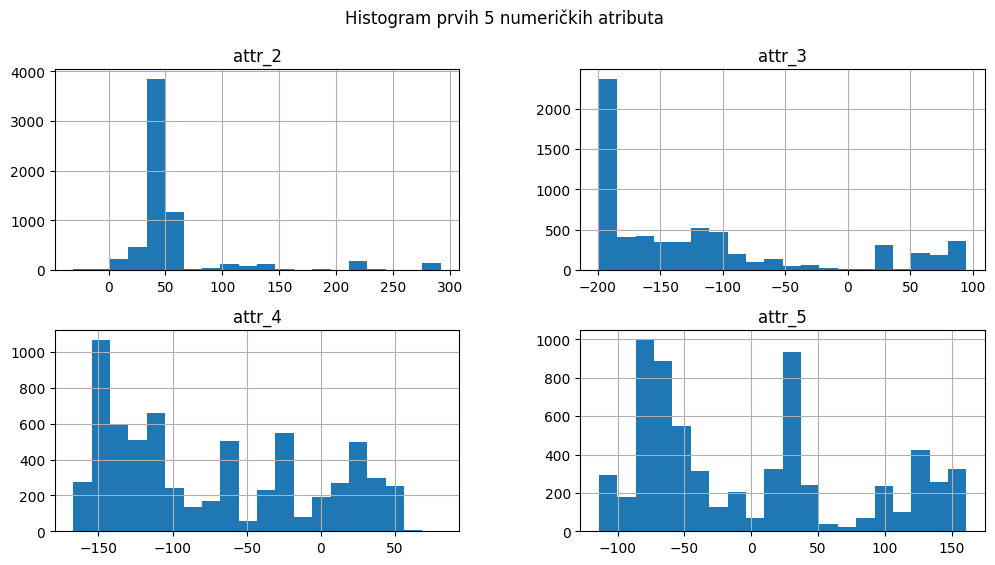

In [15]:
import matplotlib.pyplot as plt
num_cols = df.columns[1:6] #prvih 5 numerickih atributa

df[num_cols].hist(figsize=(12,6), bins=20)
plt.suptitle("Histogram prvih 5 numeričkih atributa")
plt.show()

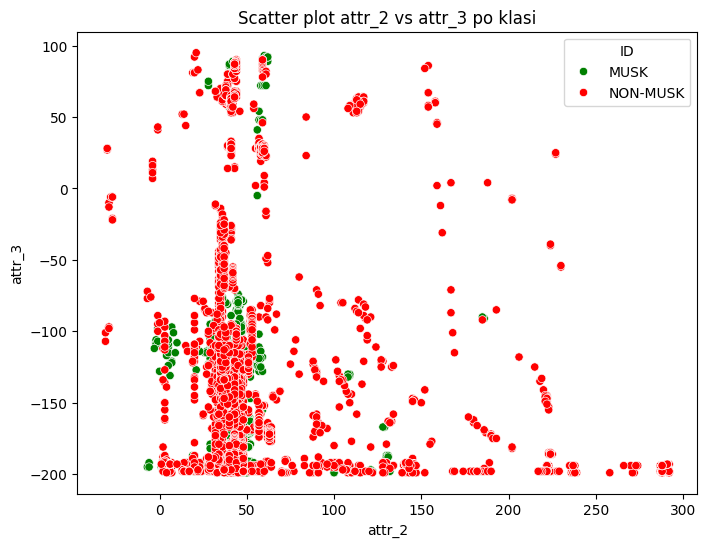

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['attr_2'], 
    y=df['attr_3'], 
    hue=df['ID'].apply(lambda x: 'MUSK' if x.startswith('MUSK') else 'NON-MUSK'),
    palette=['green','red']
)
plt.title("Scatter plot attr_2 vs attr_3 po klasi")
plt.show()

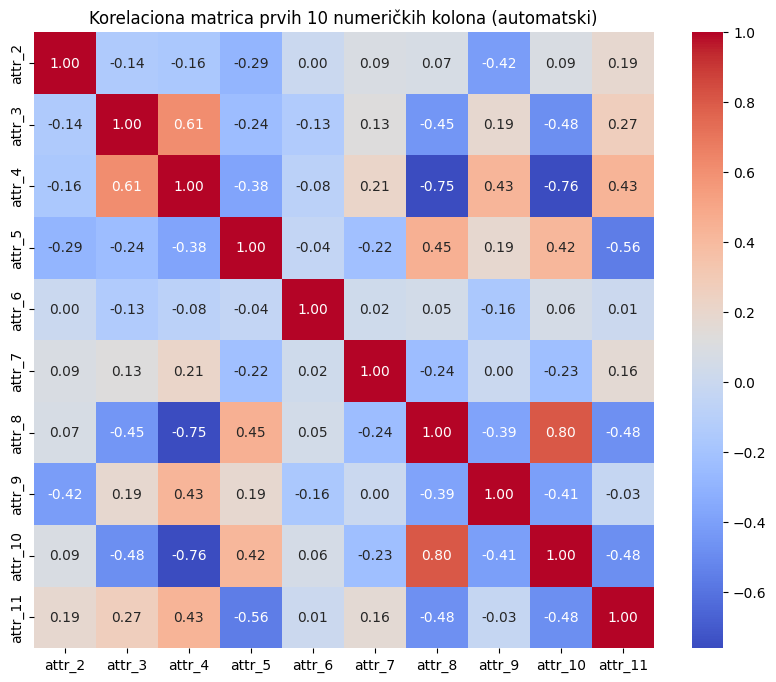

In [17]:
#Korelaciona matrica
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.iloc[:, :10].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelaciona matrica prvih 10 numeričkih kolona (automatski)")
plt.show()

Dakle vrijednost u celiji (i,j) predstavlja koeficijent korelacije izmedju atributa i sa atributom j.
Tumacenje vrijednosti:
+1 -> pozitivna linearna veza; ako jedan atribut raste i drugi raste proporcionalno
0  -> nema linearne zavisnosti
-1 -> negativna linearna veza; ako jedan atribut raste drugi opada proporcionalno
*****************
Na osnovu prikazane matrice može se uočiti da između pojedinih atributa postoji značajna korelacija, što znači da određene informacije u dataset-u mogu biti redundantne.

Ova pojava je česta kod dataset-ova sa velikim brojem atributa i predstavlja dodatnu motivaciju za primjenu metoda redukcije dimenzionalnosti, kao što je PCA, kako bi se eliminisala redundantnost i poboljšala efikasnost modela.